<a href="https://colab.research.google.com/github/Pamir116/Machine_Learning/blob/EDA_Linear_REgression/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline




In [ ]:
url="input.csv"
df=pd.read_csv(url,sep=',',header=0)

In [ ]:
print(df.shape)

(55620, 10)


In [ ]:
print(df.head())

   Year Industry_aggregation_NZSIOC Industry_code_NZSIOC Industry_name_NZSIOC  \
0  2024                     Level 1                99999       All industries   
1  2024                     Level 1                99999       All industries   
2  2024                     Level 1                99999       All industries   
3  2024                     Level 1                99999       All industries   
4  2024                     Level 1                99999       All industries   

                Units Variable_code  \
0  Dollars (millions)           H01   
1  Dollars (millions)           H04   
2  Dollars (millions)           H05   
3  Dollars (millions)           H07   
4  Dollars (millions)           H08   

                                     Variable_name      Variable_category  \
0                                     Total income  Financial performance   
1  Sales, government funding, grants and subsidies  Financial performance   
2                Interest, dividends and donati

In [ ]:
print(df.info)

<bound method DataFrame.info of        Year Industry_aggregation_NZSIOC Industry_code_NZSIOC  \
0      2024                     Level 1                99999   
1      2024                     Level 1                99999   
2      2024                     Level 1                99999   
3      2024                     Level 1                99999   
4      2024                     Level 1                99999   
...     ...                         ...                  ...   
55615  2013                     Level 3                 ZZ11   
55616  2013                     Level 3                 ZZ11   
55617  2013                     Level 3                 ZZ11   
55618  2013                     Level 3                 ZZ11   
55619  2013                     Level 3                 ZZ11   

             Industry_name_NZSIOC               Units Variable_code  \
0                  All industries  Dollars (millions)           H01   
1                  All industries  Dollars (millions)    

In [ ]:
print(df.describe())

               Year
count  55620.000000
mean    2018.500000
std        3.452084
min     2013.000000
25%     2015.750000
50%     2018.500000
75%     2021.250000
max     2024.000000


In [ ]:
exp = df[df["Variable_name"] == "Total expenditure"][["Year", "Industry_name_NZSIOC", "Value"]]
inc = df[df["Variable_name"] == "Total income"][["Year", "Industry_name_NZSIOC", "Value"]]

In [ ]:
x=exp['Value'].values
y=inc['Value'].values

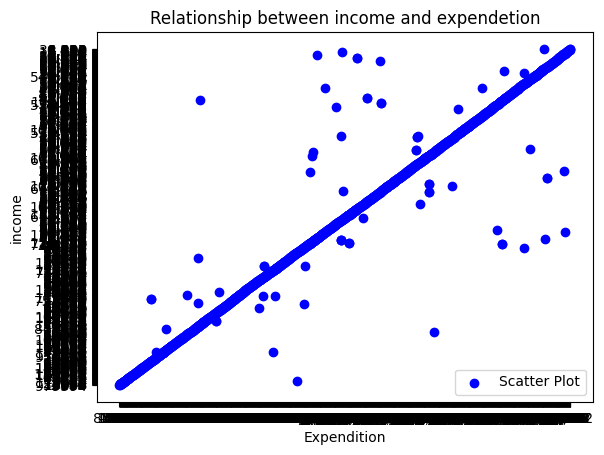

In [ ]:
plt.scatter(x, y, color = 'blue', label='Scatter Plot')
plt.title('Relationship between income and expendetion')
plt.xlabel('Expendition')
plt.ylabel('income')
plt.legend(loc=4)
plt.show()

In [ ]:
inc['Value'] = inc['Value'].astype(str).str.replace(',', '', regex=False)
exp['Value'] = exp['Value'].astype(str).str.replace(',', '', regex=False)
inc['Value'] = pd.to_numeric(inc['Value'], errors='coerce')
exp['Value'] = pd.to_numeric(exp['Value'], errors='coerce')

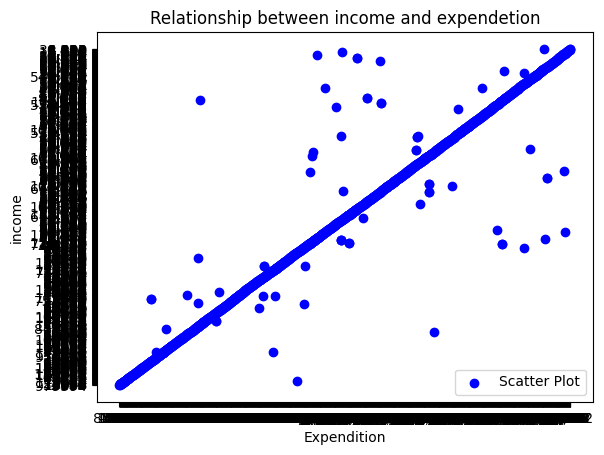

In [ ]:
plt.scatter(x,y,color='blue',label='Scatter Plot')
plt.title('Relationship between income and expendetion')
plt.xlabel('Expendition')
plt.ylabel('income')
plt.legend(loc=4)
plt.show()

In [ ]:
print(x.shape)
print(y.shape)

(1668,)
(1668,)


In [ ]:
x=x.reshape(-1,1)
y=y.reshape(-1,1)

In [ ]:
print(x.shape)
print(y.shape)

(1668, 1)
(1668, 1)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(1167, 1)
(501, 1)
(1167, 1)
(501, 1)


In [ ]:
inc['Value'] = inc['Value'].astype(str).str.replace(',', '', regex=False)
exp['Value'] = exp['Value'].astype(str).str.replace(',', '', regex=False)
inc['Value'] = pd.to_numeric(inc['Value'], errors='coerce')
exp['Value'] = pd.to_numeric(exp['Value'], errors='coerce')

# Combine the income and expenditure dataframes and drop rows with NaN values
merged_df = pd.merge(exp, inc, on=['Year', 'Industry_name_NZSIOC'], suffixes=('_exp', '_inc'))
merged_df.dropna(inplace=True)

x = merged_df['Value_exp'].values.reshape(-1, 1)
y = merged_df['Value_inc'].values.reshape(-1, 1)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1549, 1)
(665, 1)
(1549, 1)
(665, 1)


In [ ]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression()
lm.fit(x_train,y_train)
y_pred=lm.predict(x_test)

In [ ]:
a=lm.coef_
b=lm.intercept_
print("Estimate model slope, a:",a)
print("estimate model intercept b:",b)


Estimate model slope, a: [[1.13632587]]
estimate model intercept b: [6.66369757]


In [ ]:
lm.predict(x)

array([[973792.48017179],
       [ 55576.40765649],
       [  6399.63303509],
       ...,
       [  1675.92639874],
       [  2299.76930068],
       [ 40348.50468952]])

In [ ]:
print(str(lm.predict([[24]])))

[[33.93551842]]


In [ ]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("RMSE value :{:.4f}".format(rmse))

RMSE value :3873.9055


In [ ]:
from sklearn.metrics import r2_score
print("R2 score :{:.4f}".format(r2_score(y_test,y_pred)))

R2 score :0.9937


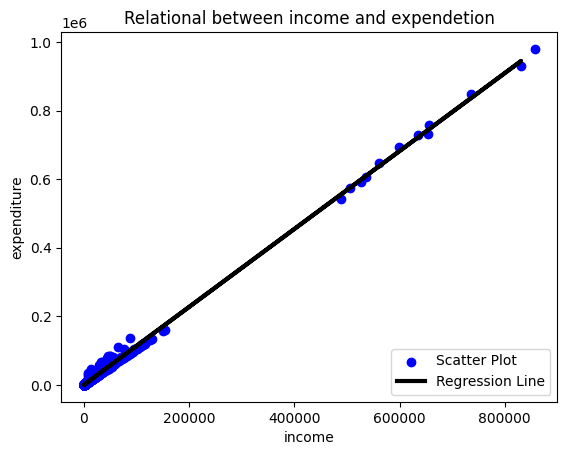

In [ ]:
plt.scatter(x,y,color='blue',label='Scatter Plot')
plt.plot(x_test,y_pred,color='black',linewidth=3 ,label='Regression Line')
plt.title('Relational between income and expendetion')
plt.xlabel('income')
plt.ylabel('expenditure')
plt.legend(loc=4)
plt.show()

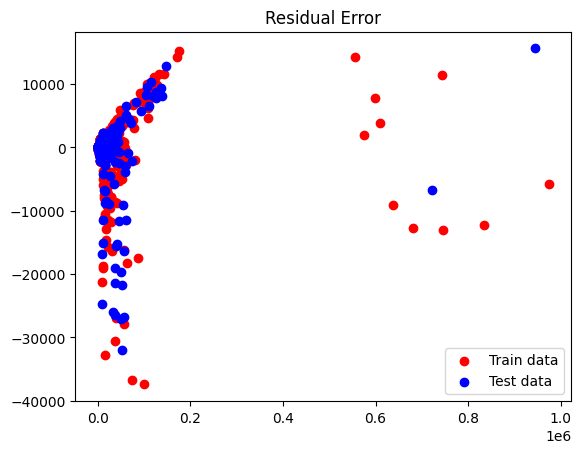

In [ ]:
plt.scatter(lm.predict(x_train),lm.predict(x_train)-y_train,color='red',label='Train data')
plt.scatter(lm.predict(x_test),lm.predict(x_test)-y_test,color='blue',label='Test data')
plt.hlines(xmin=0,xmax=50,y=0,linewidth=3)
plt.title('Residual Error')
plt.legend(loc=4)
plt.show()

In [ ]:
print("Training set score: {:.4f}".format(lm.score(x_train,y_train)))

print("Test set score: {:.4f}".format(lm.score(x_test,y_test)))

Training set score: 0.9970
Test set score: 0.9937


In [ ]:
import joblib
joblib.dump(lm, 'lm_regressor.pkl')

['lm_regressor.pkl']